У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [1]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.7/364.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmli

In [2]:
import pandas as pd

df = pd.read_csv('train.csv.zip')

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

display(df.head(10))
df.info()

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



/tmp/ipykernel_8803/1259389687.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M')['sales'].sum().reset_index()


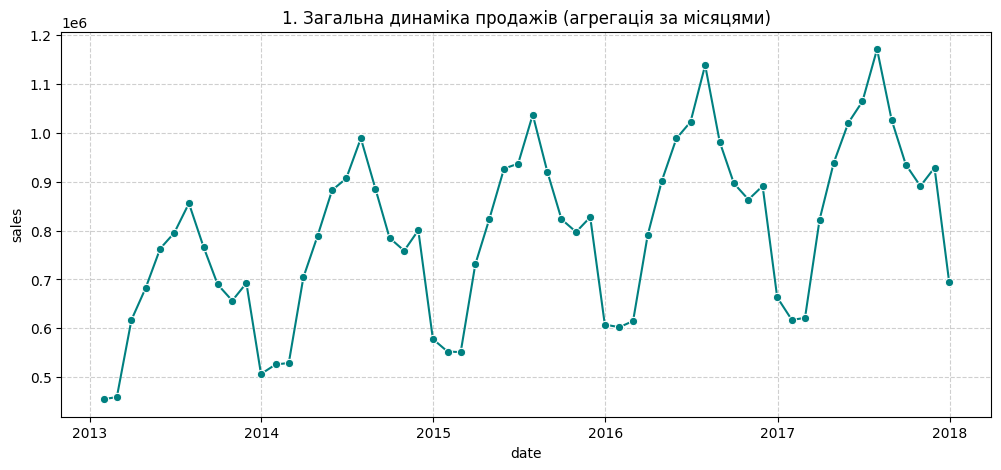

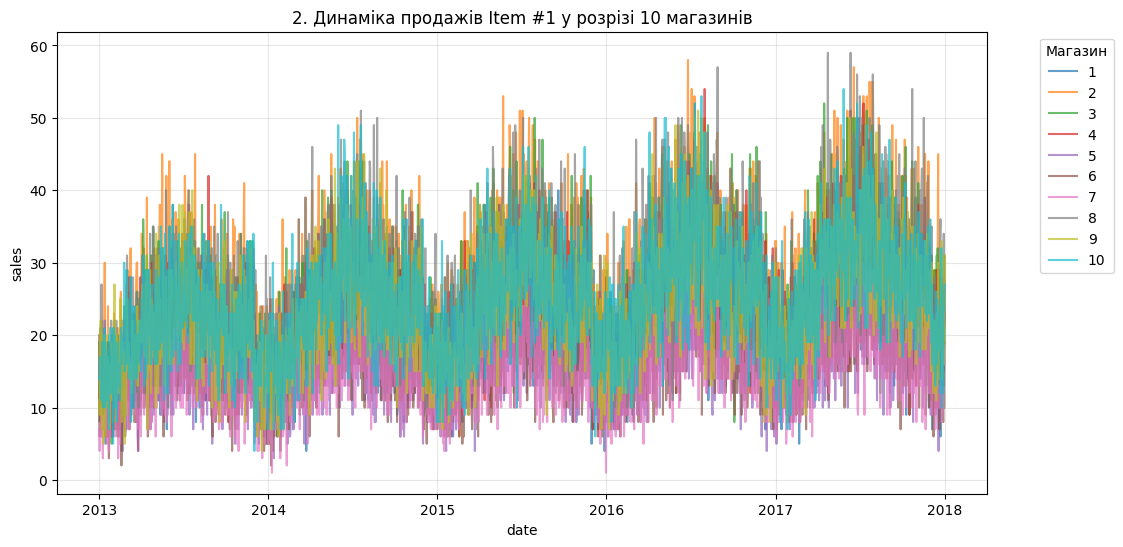

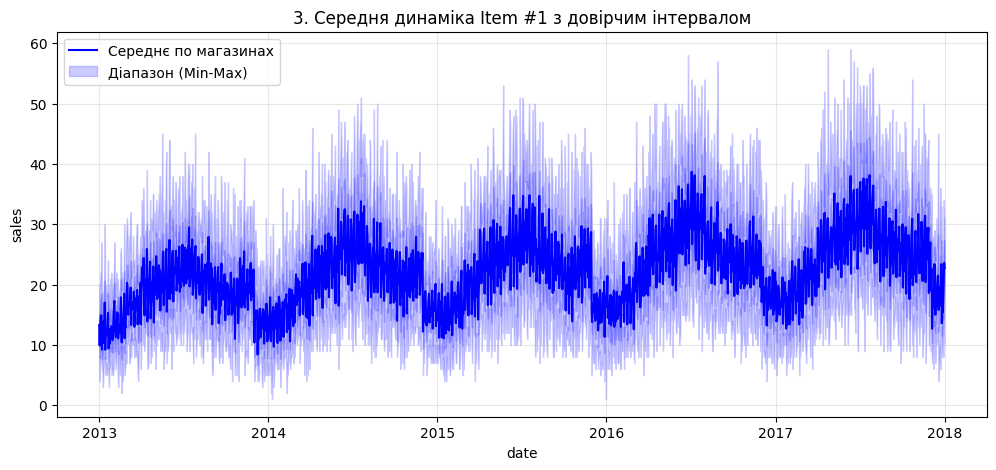

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_monthly = df.resample('M')['sales'].sum().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_monthly, x='date', y='sales', marker='o', color='teal')
plt.title('1. Загальна динаміка продажів (агрегація за місяцями)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

item_1_df = df[df['item'] == 1]
plt.figure(figsize=(12, 6))
sns.lineplot(x=item_1_df.index, y=item_1_df['sales'], hue=item_1_df['store'], palette='tab10', alpha=0.7)
plt.title('2. Динаміка продажів Item #1 у розрізі 10 магазинів')
plt.legend(title='Магазин', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(x=item_1_df.index, y=item_1_df['sales'], color='blue', label='Середнє по магазинах')

daily_min = item_1_df.groupby(level=0)['sales'].min()
daily_max = item_1_df.groupby(level=0)['sales'].max()

plt.fill_between(daily_min.index,
                 daily_min,
                 daily_max,
                 color='blue', alpha=0.2, label='Діапазон (Min-Max)')

plt.title('3. Середня динаміка Item #1 з довірчим інтервалом')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Високий сезон влітку. Висхідний тренд. Динаміка у всіх магазинах однакова але відрізняється за обсягом.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

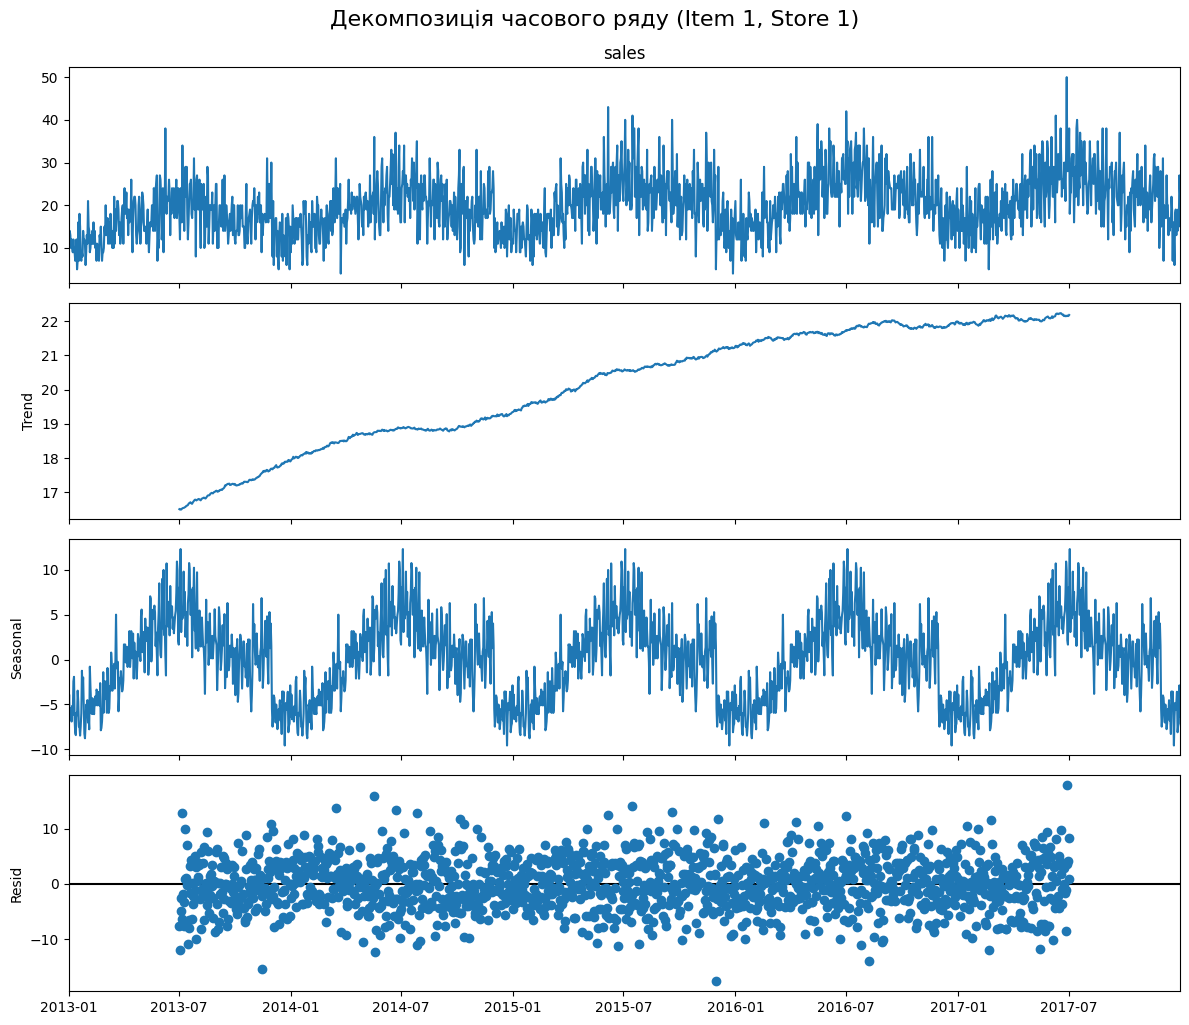

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

subset = df[(df['item'] == 1) & (df['store'] == 1)].copy()

subset = subset.asfreq('D')

decomposition = seasonal_decompose(subset['sales'], model='additive', period=365)

plt.rcParams['figure.figsize'] = (12, 10)
fig = decomposition.plot()
plt.suptitle('Декомпозиція часового ряду (Item 1, Store 1)', fontsize=16, y=1.02)
plt.show()

Тренд висхідний, продажі в цьому магазині стабільно зростають.
Видно чітку річну сезонність (продажі зростають влітку і падають взимку). В залишках є викиди, щось не враховано. Додавання інформації про святкові дні допомогла б пояснити викиди.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [5]:
from darts import TimeSeries

series = TimeSeries.from_series(subset['sales'])

print(f"Тип об'єкта: {type(series)}")
display(series.head())

Тип об'єкта: <class 'darts.timeseries.TimeSeries'>


,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

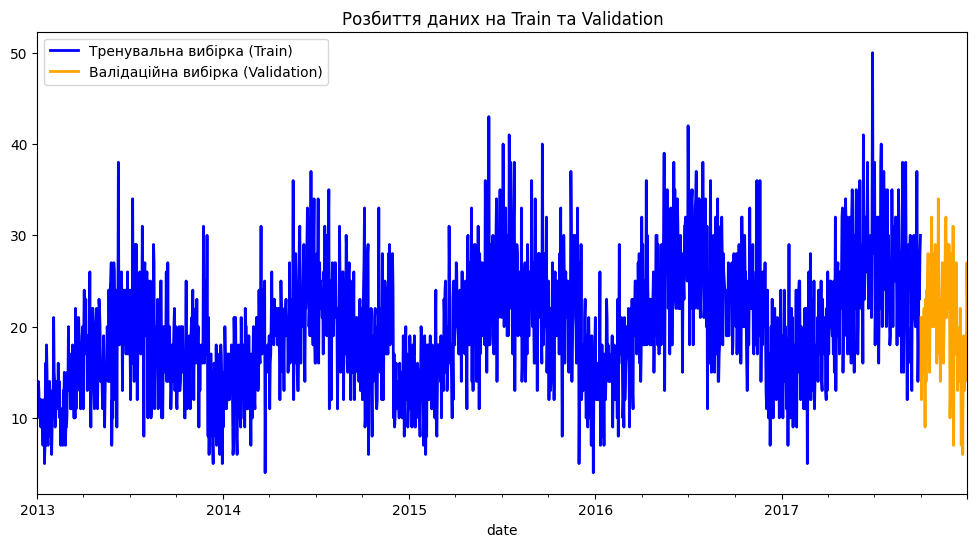

Кількість днів у навчальній вибірці: 1734
Кількість днів у валідаційній вибірці: 92


In [6]:
split_date = pd.Timestamp('2017-10-01')

train, val = series.split_before(split_date)

plt.figure(figsize=(12, 6))
train.plot(label='Тренувальна вибірка (Train)', color='blue')
val.plot(label='Валідаційна вибірка (Validation)', color='orange')

plt.title('Розбиття даних на Train та Validation')
plt.legend()
plt.show()

print(f"Кількість днів у навчальній вибірці: {len(train)}")
print(f"Кількість днів у валідаційній вибірці: {len(val)}")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1200x500 with 0 Axes>

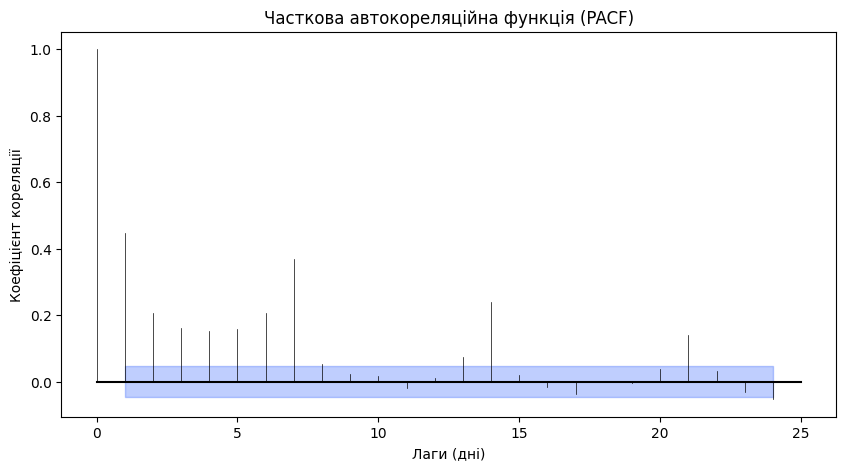

In [7]:
from darts.utils.statistics import plot_pacf

plt.figure(figsize=(12, 5))
plot_pacf(series, method='ld')

plt.title('Часткова автокореляційна функція (PACF)')
plt.xlabel('Лаги (дні)')
plt.ylabel('Коефіцієнт кореляції')
plt.show()

Лаг 1 найважливіший. Тижнева сезонність Лаги 7, 14, 21. Лаги 2–6 також є важливими, але їхній вплив поступово падає.

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [8]:
from darts.utils.statistics import check_seasonality

is_seasonal, period = check_seasonality(train, m=7, max_lag=30)

print(is_seasonal)
print(period)

True
7


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

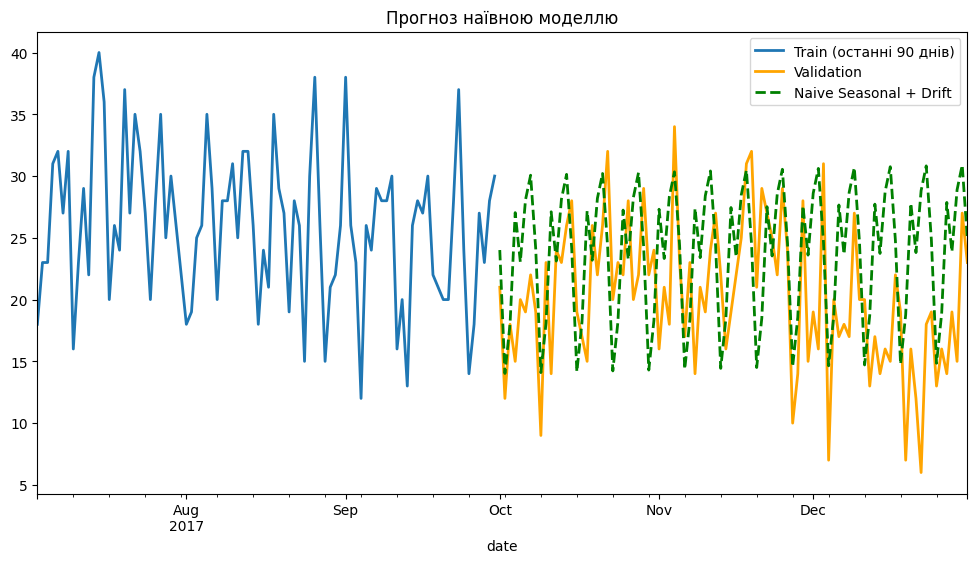

In [9]:
from darts.models import NaiveSeasonal, NaiveDrift

n_forecast = len(val)

seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_pred = seasonal_model.predict(n_forecast)

drift_model = NaiveDrift()
drift_model.fit(train)
drift_pred = drift_model.predict(n_forecast)

naive_combined_pred = seasonal_pred + (drift_pred - train.last_value())

plt.figure(figsize=(12, 6))
train[-90:].plot(label='Train (останні 90 днів)')
val.plot(label='Validation', color='orange')
naive_combined_pred.plot(label='Naive Seasonal + Drift', color='green', linestyle='--')

plt.title('Прогноз наївною моделлю')
plt.legend()
plt.show()

Модель повторює форму графіка але вона неточна

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [10]:
from darts.metrics import mape

naive_error = mape(val, naive_combined_pred)

print(f"MAPE Seasonal + Drift: {naive_error:.2f}%")

MAPE Seasonal + Drift: 39.91%


10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

MAPE XGBoost: 45.99%


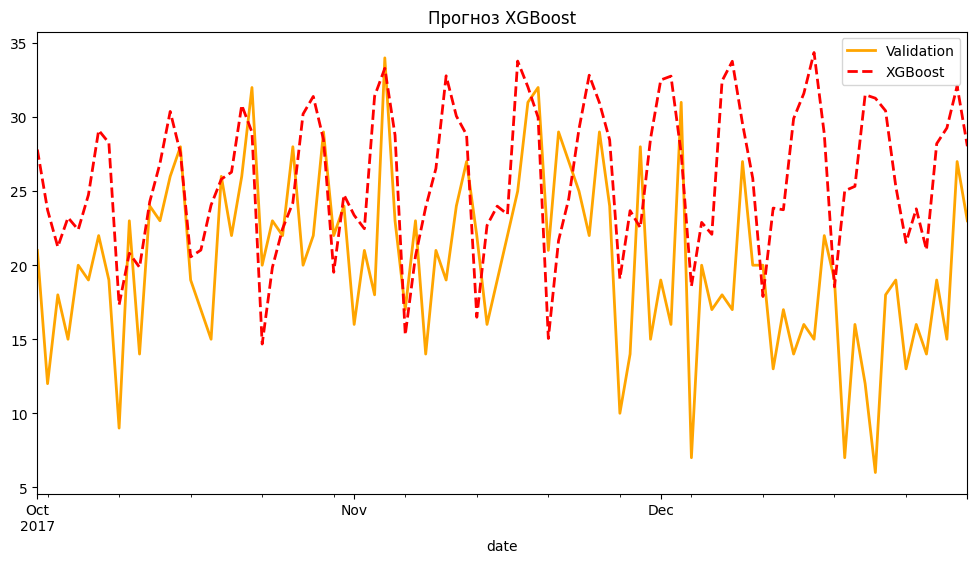

In [11]:
from darts.models import XGBModel

model_xgb = XGBModel(
    lags=31,
    add_encoders={
        'cyclic': {'future': ['month', 'dayofweek']},
        'datetime_attribute': {'future': ['year']}
    },
    random_state=42
)

model_xgb.fit(train)

xgb_pred = model_xgb.predict(len(val))

xgb_error = mape(val, xgb_pred)
print(f"MAPE XGBoost: {xgb_error:.2f}%")

plt.figure(figsize=(12, 6))
val.plot(label='Validation', color='orange')
xgb_pred.plot(label='XGBoost', color='red', linestyle='--')
plt.title('Прогноз XGBoost')
plt.legend()
plt.show()

In [12]:
import numpy as np
from darts.models import XGBModel

train_log = train.map(np.log1p)

model_xgb_tuned = XGBModel(
    lags=[-1, -2, -3, -4, -5, -6, -7, -14, -21, -28, -364],
    add_encoders={
        'cyclic': {'future': ['month', 'dayofweek']},
        'datetime_attribute': {'future': ['year']}
    },
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model_xgb_tuned.fit(train_log)
pred_log = model_xgb_tuned.predict(len(val))

xgb_tuned_pred = pred_log.map(np.expm1)

print(f"MAPE XGBoost: {mape(val, xgb_tuned_pred):.2f}%")

MAPE XGBoost: 28.35%


Після підбору параметрів якість моделі покращилася.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

MAPE Exponential Smoothing: 39.01%


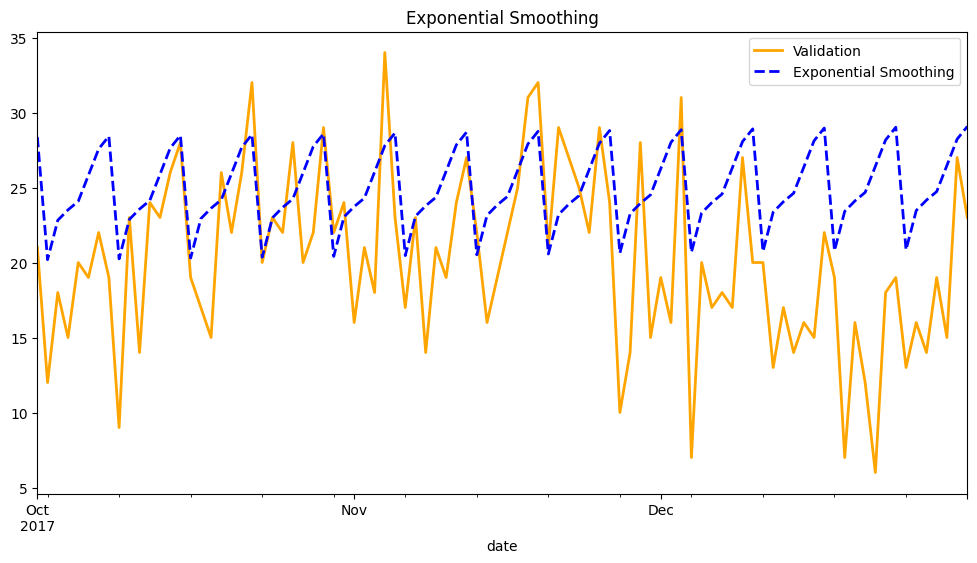

In [13]:
from darts.models import ExponentialSmoothing

model_es = ExponentialSmoothing(seasonal_periods=7)
model_es.fit(train)

es_pred = model_es.predict(len(val))

es_error = mape(val, es_pred)
print(f"MAPE Exponential Smoothing: {es_error:.2f}%")

plt.figure(figsize=(12, 6))
val.plot(label='Validation', color='orange')
es_pred.plot(label='Exponential Smoothing', color='blue', linestyle='--')
plt.title('Exponential Smoothing')
plt.legend()
plt.show()

Модель спрацювала майже на рівні з наївною моделлю

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAPE ARIMA (7, 1, 1): 39.53%


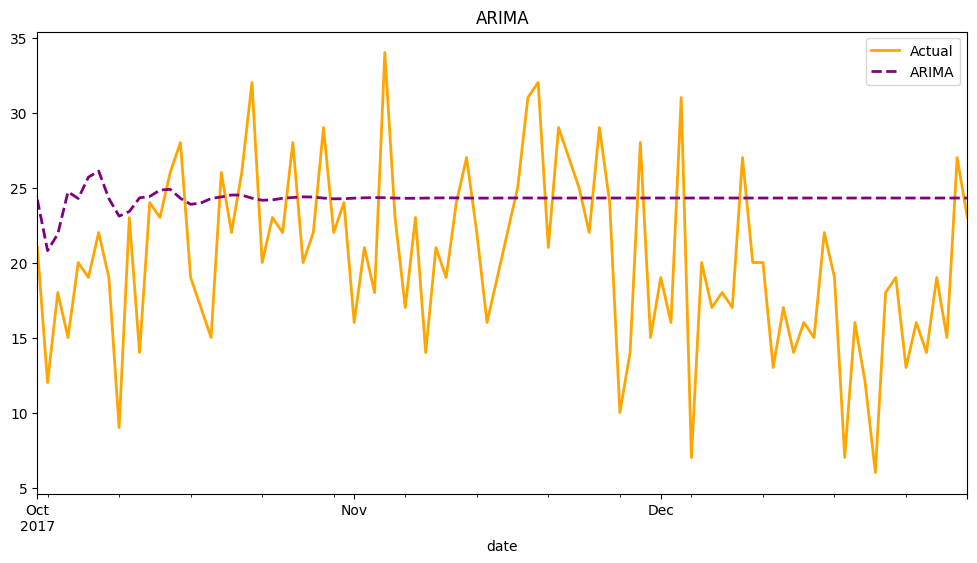

In [14]:
from darts.models import ARIMA

model_arima = ARIMA(p=7, d=1, q=1)

model_arima.fit(train)

arima_pred = model_arima.predict(len(val))

arima_error = mape(val, arima_pred)
print(f"MAPE ARIMA (7, 1, 1): {arima_error:.2f}%")

plt.figure(figsize=(12, 6))
val.plot(label='Actual', color='orange')
arima_pred.plot(label='ARIMA', color='purple', linestyle='--')
plt.title('ARIMA')
plt.legend()
plt.show()

Модель показує результати на рівні з наївною моделлю. Необхідно точніше підбрати параметри.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

In [1]:
!pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [15]:
from darts.models import AutoARIMA
from darts.metrics import mape

model_auto_arima = AutoARIMA(seasonal=True)

model_auto_arima.fit(train)

auto_arima_pred = model_auto_arima.predict(len(val))
auto_arima_error = mape(val, auto_arima_pred)

print(f"MAPE AutoARIMA: {auto_arima_error:.2f}%")

MAPE AutoARIMA: 40.29%


AutoARIMA спрацювала гірше ніж ручна модель ARIMA.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAPE Prophet: 23.80%


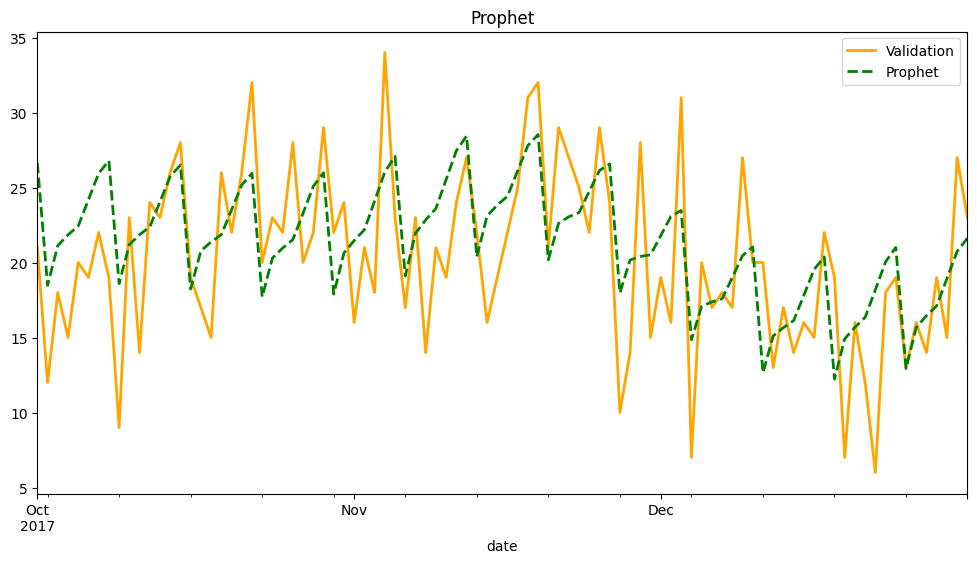

In [16]:
from darts.models import Prophet

model_prophet = Prophet()
model_prophet.fit(train)

prophet_pred = model_prophet.predict(len(val))

prophet_error = mape(val, prophet_pred)
print(f"MAPE Prophet: {prophet_error:.2f}%")

plt.figure(figsize=(12, 6))
val.plot(label='Validation', color='orange')
prophet_pred.plot(label='Prophet', color='green', linestyle='--')
plt.title('Prophet')
plt.legend()
plt.show()

Prophet новий лідер

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

In [2]:
!pip install "u8darts[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 744.5/744.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.9 MB/s eta 0:00:00
  Attempting uninstall: darts
    Found existing installation: darts 0.44.0
    Uninstalling darts-0.44.0:
      Successfully uninstalled darts-0.44.0


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 1.8 K  | train
6 | V               | Linear           | 21     | train
-------------------------------------------------------------
1.9 K     Trainable params
0         Non-trainable params
1.9 K     Total params
0.007     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

MAPE моделі RNN (LSTM): 29.87%


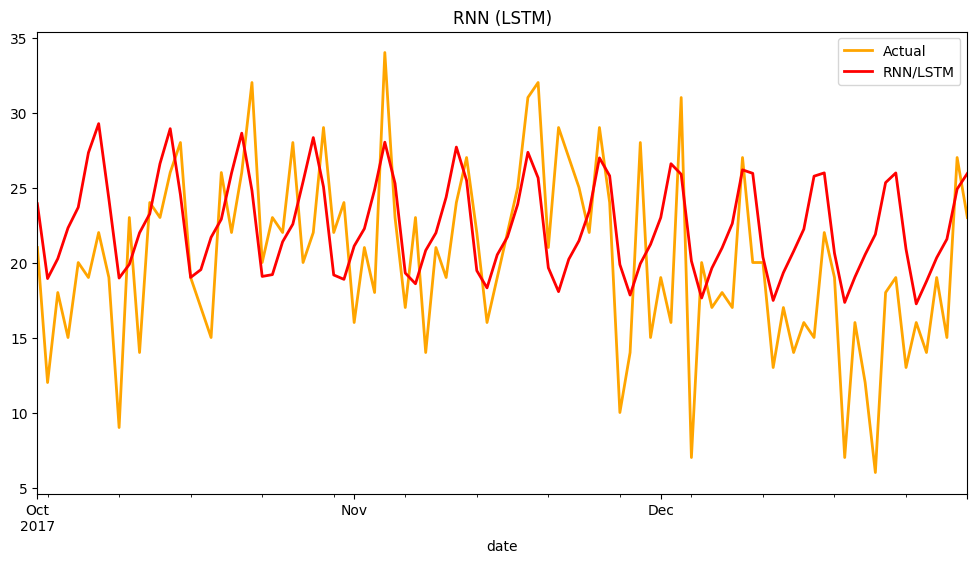

In [17]:
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler

scaler = Scaler()
train_scaled = scaler.fit_transform(train)

model_rnn = RNNModel(
    model='LSTM',
    input_chunk_length=30,
    output_chunk_length=1,
    hidden_dim=20,
    n_rnn_layers=1,
    n_epochs=100,
    random_state=42,
    training_length=31
)

model_rnn.fit(train_scaled, verbose=True)

pred_scaled = model_rnn.predict(len(val))
rnn_pred = scaler.inverse_transform(pred_scaled)

rnn_error = mape(val, rnn_pred)
print(f"MAPE моделі RNN (LSTM): {rnn_error:.2f}%")

plt.figure(figsize=(12, 6))
val.plot(label='Actual', color='orange')
rnn_pred.plot(label='RNN/LSTM', color='red')
plt.title('RNN (LSTM)')
plt.legend()
plt.show()

Модель LSTM перевершила наївну модель але показує гірші результати за Prophet та XGBoost. LSTM потребуює значно більше часу на навчання. Її використання не є оптимальним, оскільки Prophet дає значно вищу точність за менший  час

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

historical forecasts: 100%|██████████| 12/12 [00:04<00:00,  2.60it/s]


MAPE під час бектесту: 24.49%


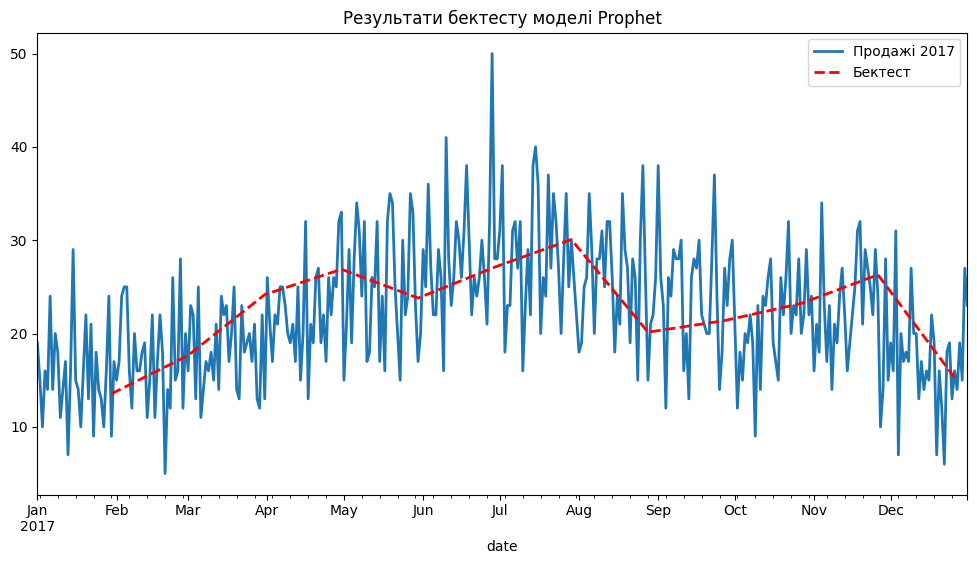

In [19]:

backtest_series = model_prophet.historical_forecasts(
    series=series,
    start=pd.Timestamp('2017-01-01'),
    forecast_horizon=30,
    stride=30,
    retrain=True,
    verbose=True
)

backtest_mape = mape(series, backtest_series)
print(f"MAPE під час бектесту: {backtest_mape:.2f}%")

plt.figure(figsize=(12, 6))
series[-365:].plot(label='Продажі 2017')
backtest_series.plot(label='Бектест', color='red', linestyle='--')

plt.title('Результати бектесту моделі Prophet')
plt.legend()
plt.show()

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

1. Я б обрав модель XGBoost. Хоча Prophet найточніша для одного ряду, але її потрібно тренувати 500 разів окремо для кожного ряду.
2. Я б тренував 1 або 2 моделі на всі 500 рядів.
3. Глобальні моделі бачать спільні тренди. Можемо додати більше контексту. Легше оновлювати та моніторити одну модель. При правильному підборі параметрів точність можна покращити, як видно з завдання 10.

